# RQ 2 - How effective is the Multiple AI-Agents layer in improving FL system evaluation metrics?

Using results from: /Users/ivan/Desktop/AP4Fed/Experiments_100r_Docker


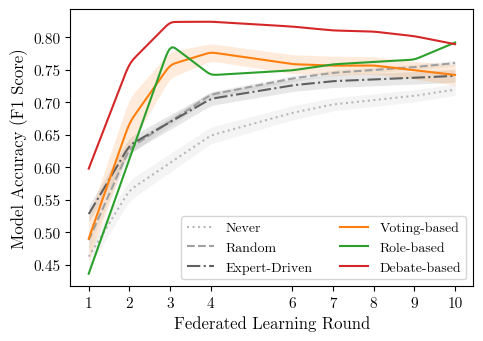

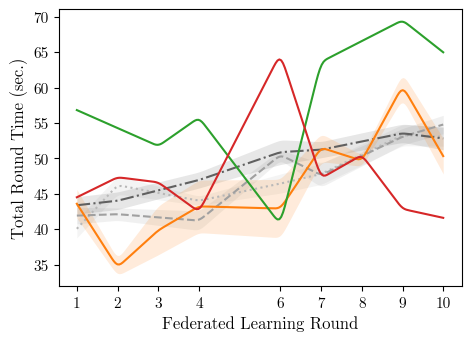

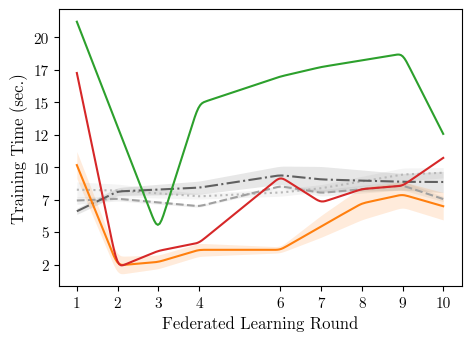

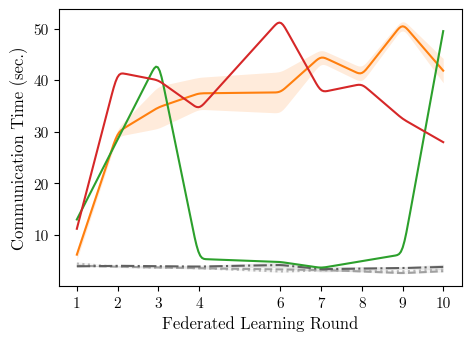

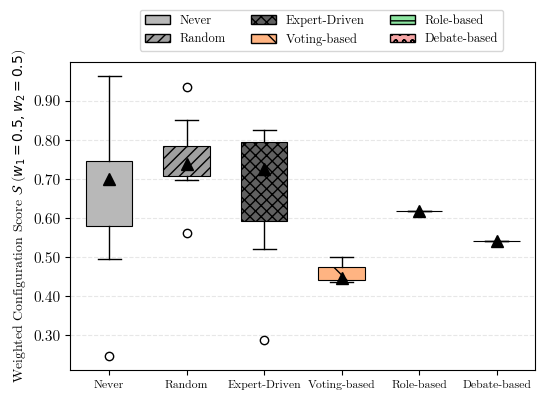

In [2]:
import re
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
from scipy.stats import mannwhitneyu

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

ROOT = Path("/Users/ivan/Desktop/AP4Fed/Experiments_100r_Docker")
if not ROOT.exists():
    raise FileNotFoundError(f"Results folder not found: {ROOT}")
print(f"Using results from: {ROOT}")

plt.rcParams["font.family"] = "CMU Serif"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10

FOLDERS = {
    "never": "Never",
    "expert-driven": "Expert-Driven",
    "random": "Random",
    "voting-based": "Voting-based",
    "role-based": "Role-based",
    "debate-based": "Debate-based",
}
ORDER = ["Never", "Random", "Expert-Driven", "Voting-based", "Role-based", "Debate-based"]
BASELINES = ["Never", "Random", "Expert-Driven"]
AGENTS = ["Voting-based", "Role-based", "Debate-based"]

COLORS = {
    "Never": "#b8b8b8",
    "Random": "#a0a0a0",
    "Expert-Driven": "#606060",
    "Voting-based": "#ff7f0e",
    "Role-based": "#2ca02c",
    "Debate-based": "#d62728",
}
LINESTYLES = {
    "Never": ":",
    "Random": "--",
    "Expert-Driven": "-.",
    "Voting-based": "-",
    "Role-based": "-",
    "Debate-based": "-",
}
AGENT_COLORS = {
    "Voting-based": "#FFB482",
    "Role-based": "#8DE5A1",
    "Debate-based": "#F6A6A6",
}
HATCHES = {
    "Never": "",
    "Random": "///",
    "Expert-Driven": "XXX",
    "Voting-based": "\\",
    "Role-based": "--",
    "Debate-based": "oo",
}
FIGSIZE = (5.2, 3.6)
BOX_FIGSIZE = (6.0, 4.0)

STAT_METRICS = [
    ("Model Accuracy", "acc", True),
    ("Training Time", "training_time", False),
    ("Communication Time", "communication_time", False),
    ("Total Round Time", "total_time", False),
]

STAT_METRIC_ORDER = {label: idx for idx, (label, _, _) in enumerate(STAT_METRICS)}
BASELINE_ORDER_INDEX = {name: idx for idx, name in enumerate(BASELINES)}
AGENT_ORDER_INDEX = {name: idx for idx, name in enumerate(AGENTS)}


def normalize_approach(value):
    s = str(value).strip()
    sl = s.lower()
    if sl in FOLDERS:
        return FOLDERS[sl]
    for item in ORDER:
        if sl == item.lower():
            return item
    return s


def load_round_metrics(root: Path) -> pd.DataFrame:
    round_metrics_path = root / "round_metrics.csv"
    if round_metrics_path.exists():
        df = pd.read_csv(round_metrics_path).copy()
        expected = ["approach", "run", "round", "F1", "total_time", "training_time", "communication_time"]
        missing = [col for col in expected if col not in df.columns]
        if missing:
            raise ValueError(f"Missing columns in {round_metrics_path}: {missing}")
        df = df[expected].copy()
        df["approach"] = df["approach"].map(normalize_approach)
        return df

    rows = []
    for folder_name, display_name in FOLDERS.items():
        folder_path = root / folder_name
        if not folder_path.exists():
            continue
        for path in sorted(folder_path.glob("r[0-9]*.csv")):
            if not re.fullmatch(r"r\d+\.csv", path.name):
                continue
            df = pd.read_csv(path)
            time_col = next((c for c in ["Total Round Time", "Total Time of FL Round", "Total Time"] if c in df.columns), None)
            round_col = next((c for c in df.columns if c.lower() == "fl round" or "fl round" in c.lower()), None)
            f1_col = next((c for c in df.columns if c.lower() == "val f1" or ("f1" in c.lower() and "val" in c.lower())), None)
            training_col = next((c for c in df.columns if c.lower() == "training time"), None)
            comm_col = next((c for c in df.columns if c.lower() == "communication time"), None)
            if not time_col or not round_col or not f1_col:
                continue
            temp = df.copy()
            for col in [round_col, f1_col, time_col, training_col, comm_col]:
                if col is not None:
                    temp[col] = pd.to_numeric(
                        temp[col]
                        .astype(str)
                        .str.replace("\u202f", "", regex=False)
                        .str.replace(" ", "", regex=False)
                        .str.replace(",", ".", regex=False),
                        errors="coerce",
                    )
            temp = temp.dropna(subset=[round_col]).sort_values(round_col)
            for round_id, sub in temp.groupby(round_col):
                row = sub.tail(1).iloc[0]
                rows.append(
                    {
                        "approach": display_name,
                        "run": path.stem,
                        "round": int(round_id),
                        "F1": row.get(f1_col, np.nan),
                        "total_time": row.get(time_col, np.nan),
                        "training_time": row.get(training_col, np.nan) if training_col else np.nan,
                        "communication_time": row.get(comm_col, np.nan) if comm_col else np.nan,
                    }
                )
    if not rows:
        raise ValueError(f"No round-level experiment rows found in {root}")
    return pd.DataFrame(rows)


def finite_values(values):
    arr = np.asarray(values, dtype=float)
    return arr[np.isfinite(arr)]


def vargha_delaney_a12(x, y, higher_is_better=True):
    x, y = finite_values(x), finite_values(y)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    if not higher_is_better:
        x, y = -x, -y
    more = 0.0
    equal = 0.0
    for xi in x:
        for yj in y:
            if xi > yj:
                more += 1.0
            elif xi == yj:
                equal += 1.0
    return float((more + 0.5 * equal) / (len(x) * len(y)))


def mann_whitney_pvalue(x, y):
    x, y = finite_values(x), finite_values(y)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    return float(mannwhitneyu(x, y, alternative="two-sided").pvalue)


def a12_symbol(a12, pvalue):
    if np.isnan(a12) or np.isnan(pvalue) or pvalue >= 0.05:
        return "-"
    if a12 > 0.70:
        return "✓✓✓"
    if a12 > 0.63:
        return "✓✓"
    if a12 > 0.55:
        return "✓"
    if a12 < 0.30:
        return "✗✗✗"
    if a12 < 0.37:
        return "✗✗"
    if a12 < 0.45:
        return "✗"
    return "-"


def mean_std(values):
    arr = finite_values(values)
    if len(arr) == 0:
        return np.nan, np.nan, 0
    return float(np.mean(arr)), (float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0), int(len(arr))


def fmt_acc(mean, std):
    return f"{mean:.2f} ± {std:.2f}" if np.isfinite(mean) else ""


def fmt_sec(mean, std):
    return f"{int(round(mean))} ± {int(round(std))} s" if np.isfinite(mean) else ""


def pick_xticks(values, target=10):
    values = list(values)
    if len(values) <= target:
        return values
    idxs = np.linspace(0, len(values) - 1, target, dtype=int)
    return [values[idx] for idx in idxs]


def kfmt(x, pos):
    if x == 0:
        return "0"
    if abs(x) >= 1000:
        value = x / 1000.0
        return f"{value:.1f}k" if (value % 1) else f"{int(value)}k"
    return f"{int(x)}"


def light_smooth(x, y, num_points=200):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 4:
        return x, y
    x_new = np.linspace(x.min(), x.max(), num_points)
    y_interp = np.interp(x_new, x, y)
    window = min(11, len(y_interp) - (len(y_interp) + 1) % 2)
    if window < 5:
        return x_new, y_interp
    kernel = np.blackman(window)
    kernel /= kernel.sum()
    y_smoothed = np.convolve(y_interp, kernel, mode="same")
    y_smoothed[:window] = y_interp[:window]
    y_smoothed[-window:] = y_interp[-window:]
    return x_new, y_smoothed


def minmax_norm(series: pd.Series) -> pd.Series:
    smin = series.min()
    smax = series.max()
    if pd.isna(smin) or pd.isna(smax):
        return pd.Series(np.nan, index=series.index)
    if np.isclose(smax, smin):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - smin) / (smax - smin)


def inv_minmax_norm(series: pd.Series) -> pd.Series:
    smin = series.min()
    smax = series.max()
    if pd.isna(smin) or pd.isna(smax):
        return pd.Series(np.nan, index=series.index)
    if np.isclose(smax, smin):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (smax - series) / (smax - smin)


G = load_round_metrics(ROOT)
for col in ["round", "F1", "total_time", "training_time", "communication_time"]:
    G[col] = pd.to_numeric(G[col], errors="coerce")
G["approach"] = G["approach"].map(normalize_approach)
G = G.dropna(subset=["approach", "run", "round", "F1", "total_time"]).copy()

A = G.groupby(["approach", "round"]).agg(
    {
        "F1": ["mean", "std", "count"],
        "total_time": ["mean", "std", "count"],
        "training_time": ["mean", "std", "count"],
        "communication_time": ["mean", "std", "count"],
    }
)

present = [approach for approach in ORDER if approach in A.index.get_level_values("approach").unique()]
xt = sorted(int(value) for value in A.index.get_level_values("round").unique())
if not xt:
    raise ValueError("No round values available for plotting")


def draw(metric, ylabel, yfmt=False, fname=None, show_legend=False):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.grid(False)

    for approach in present:
        stat = A.loc[approach, metric]
        x = stat.index.values.astype(float)
        y = stat["mean"].values.astype(float)
        s = stat["std"].fillna(0).values.astype(float)
        n = stat["count"].clip(lower=1).values.astype(float)
        ci = 0.5 * s / np.sqrt(n)
        lo, hi = y - ci, y + ci
        if metric == "F1":
            lo, hi = np.clip(lo, 0, 1), np.clip(hi, 0, 1)

        if len(x) > 5:
            xf, yf = light_smooth(x, y)
            _, lof = light_smooth(x, lo)
            _, hif = light_smooth(x, hi)
            ax.plot(xf, yf, linestyle=LINESTYLES[approach], label=approach, color=COLORS[approach], linewidth=1.5, zorder=3)
            ax.fill_between(xf, lof, hif, alpha=0.15, color=COLORS[approach], lw=0, zorder=2)
        else:
            ax.plot(x, y, linestyle=LINESTYLES[approach], label=approach, color=COLORS[approach], linewidth=1.5, zorder=3)
            ax.fill_between(x, lo, hi, alpha=0.15, color=COLORS[approach], lw=0, zorder=2)

    ax.set_xlabel("Federated Learning Round")
    ax.set_ylabel(ylabel)
    ax.set_xticks(pick_xticks(xt))
    if yfmt:
        ax.yaxis.set_major_formatter(FuncFormatter(kfmt))
    if show_legend:
        ax.legend(ncol=2, frameon=True, loc="best", fontsize=10)

    fig.savefig(ROOT / (fname or f"{metric}.pdf"), bbox_inches="tight", dpi=600)
    plt.show()


def draw_score_boxplot(df_source, value_col, ylabel, fname):
    fig, ax = plt.subplots(figsize=BOX_FIGSIZE)
    ax.grid(True, axis="y", linestyle="--", alpha=0.3, zorder=0)
    ax.grid(False, axis="x")

    data, labels = [], []
    for approach in ORDER:
        sub = df_source.loc[df_source["approach"] == approach, value_col].dropna()
        if sub.empty:
            continue
        data.append(sub.values)
        labels.append(approach)

    if not data:
        raise ValueError("No score values available for boxplot")

    bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.6, zorder=3)
    for patch, label in zip(bp["boxes"], labels):
        face = AGENT_COLORS.get(label, COLORS.get(label, "#cccccc"))
        patch.set(facecolor=face, edgecolor="black", linewidth=0.8, hatch=HATCHES.get(label, ""), zorder=3)

    for median in bp["medians"]:
        x, y = median.get_xdata(), median.get_ydata()
        ax.plot(np.mean(x), np.mean(y), marker="^", markersize=8, color="black", zorder=10)
        median.set_alpha(0)

    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.2f}"))
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis="x", labelsize=8.5)

    legend_patches = [
        mpatches.Patch(facecolor=AGENT_COLORS.get(label, COLORS[label]), hatch=HATCHES.get(label, ""), label=label, edgecolor="black")
        for label in labels
    ]
    ax.legend(handles=legend_patches, loc="upper center", bbox_to_anchor=(0.54, 1.19), ncol=3, fontsize=9, frameon=True)

    fig.savefig(ROOT / fname, bbox_inches="tight", dpi=600)
    plt.show()


run_rows = []
for (approach, run), sub in G.groupby(["approach", "run"]):
    sub = sub.sort_values("round")
    f1_vals = sub["F1"].dropna()
    tr_vals = sub["training_time"].dropna()
    cm_vals = sub["communication_time"].dropna()
    tt_vals = sub["total_time"].dropna()

    run_rows.append(
        {
            "approach": approach,
            "run": run,
            "acc": float(f1_vals.iloc[-1]) if len(f1_vals) else np.nan,
            "training_time": float(tr_vals.mean()) if len(tr_vals) else np.nan,
            "communication_time": float(cm_vals.mean()) if len(cm_vals) else np.nan,
            "total_time": float(tt_vals.mean()) if len(tt_vals) else np.nan,
            "total_fl_time": float(tt_vals.sum()) if len(tt_vals) else np.nan,
        }
    )

RUNS = pd.DataFrame(run_rows)
RUNS = RUNS[RUNS["approach"].isin(ORDER)].copy()

stat_rows = []
for agent in AGENTS:
    xsub = RUNS[RUNS["approach"] == agent]
    if xsub.empty:
        continue
    for baseline in BASELINES:
        ysub = RUNS[RUNS["approach"] == baseline]
        if ysub.empty:
            continue
        for metric_label, metric_key, higher_is_better in STAT_METRICS:
            x = xsub[metric_key].values
            y = ysub[metric_key].values
            pvalue = mann_whitney_pvalue(x, y)
            a12 = vargha_delaney_a12(x, y, higher_is_better=higher_is_better)
            stat_rows.append(
                {
                    "agent_key": agent,
                    "baseline_key": baseline,
                    "Metric": metric_label,
                    "Agent": agent,
                    "Baseline": baseline,
                    "p_value": pvalue,
                    "A12": a12,
                    "Effect": a12_symbol(a12, pvalue),
                }
            )

STAT_DETAILS = pd.DataFrame(stat_rows)
if not STAT_DETAILS.empty:
    STAT_DETAILS = STAT_DETAILS.assign(
        _metric_order=lambda df: df["Metric"].map(STAT_METRIC_ORDER).fillna(999).astype(int),
        _agent_order=lambda df: df["agent_key"].map(AGENT_ORDER_INDEX).fillna(999).astype(int),
        _baseline_order=lambda df: df["baseline_key"].map(BASELINE_ORDER_INDEX).fillna(999).astype(int),
    ).sort_values(["_metric_order", "_agent_order", "_baseline_order"]).drop(columns=["_metric_order", "_agent_order", "_baseline_order"])

    details_to_save = STAT_DETAILS.copy()
    details_to_save["A12"] = details_to_save["A12"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "")
    details_to_save["p_value"] = details_to_save["p_value"].map(lambda x: f"{x:.4f}" if pd.notna(x) else "")
    (ROOT / "RQ2_stats_detailed.csv").write_text(details_to_save.to_csv(index=False), encoding="utf-8")

METRIC_SHORT = {
    "Model Accuracy": "Accuracy",
    "Training Time": "Training",
    "Communication Time": "Communication",
    "Total Round Time": "Round Time",
}

if not STAT_DETAILS.empty:
    ordered_metric_cols = [
        (metric_label, baseline)
        for metric_label, _, _ in STAT_METRICS
        for baseline in BASELINES
        if ((STAT_DETAILS["Metric"] == metric_label) & (STAT_DETAILS["Baseline"] == baseline)).any()
    ]

    stat_table = (
        STAT_DETAILS
        .pivot_table(
            index="Agent",
            columns=["Metric", "Baseline"],
            values="Effect",
            aggfunc="first",
        )
    )

    ordered_agents = [agent for agent in AGENTS if agent in stat_table.index]
    existing_cols = [col for col in ordered_metric_cols if col in stat_table.columns]

    stat_table = (
        stat_table
        .reindex(index=ordered_agents, columns=pd.MultiIndex.from_tuples(existing_cols))
        .reset_index()
    )

    stat_styler = stat_table.style
    if hasattr(stat_styler, "set_caption"):
        stat_styler = stat_styler.set_caption("Statistical Analysis")
    if hasattr(stat_styler, "hide"):
        stat_styler = stat_styler.hide(axis="index")
    else:
        stat_styler = stat_styler.hide_index()
    display(stat_styler)

    stat_table_csv = stat_table.copy()
    stat_table_csv.columns = [
        "Agent" if col == "Agent" else f"{METRIC_SHORT.get(col[0], col[0])} | {col[1]}"
        for col in stat_table_csv.columns
    ]
    (ROOT / "RQ2_stats_combined.csv").write_text(stat_table_csv.to_csv(index=False), encoding="utf-8")
    
W1 = 0.5
W2 = 0.5

RUNS_SCORE = RUNS.copy()
RUNS_SCORE["acc_norm"] = minmax_norm(RUNS_SCORE["acc"])
RUNS_SCORE["time_norm"] = inv_minmax_norm(RUNS_SCORE["total_fl_time"])
RUNS_SCORE["score_sim"] = W1 * RUNS_SCORE["acc_norm"] + W2 * RUNS_SCORE["time_norm"]

draw("F1", "Model Accuracy (F1 Score)", False, "F1.pdf", show_legend=True)
draw("total_time", "Total Round Time (sec.)", True, "TotalTime.pdf")
draw("training_time", "Training Time (sec.)", True, "TrainingTime.pdf")
draw("communication_time", "Communication Time (sec.)", True, "CommTime.pdf")
draw_score_boxplot(
    RUNS_SCORE,
    "score_sim",
    rf"Weighted Configuration Score $\mathcal{{S}}$ ($w_1={W1}, w_2={W2}$)",
    "ScoreSim_Boxplot.pdf",
)

# RQ3 - What is the computational overhead introduced by the Multiple AI-Agents layer?

Using results from: /Users/ivan/Desktop/AP4Fed/Experiments_100r_Docker


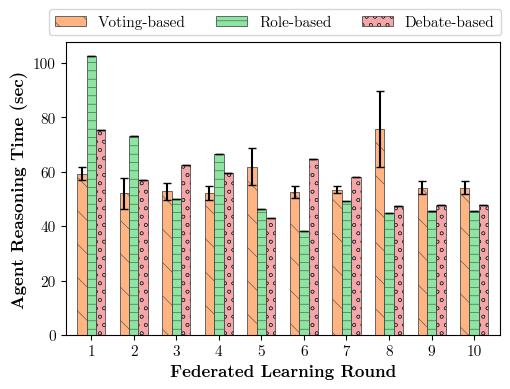

Comparison,Mean Overhead per Round,Total Overhead per Run
Role-based vs Debate-based,-,-
Voting-based vs Debate-based,-,-
Voting-based vs Role-based,-,-


In [3]:
import re
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

ROOT = Path("/Users/ivan/Desktop/AP4Fed/Experiments_100r_Docker")
if not ROOT.exists():
    raise FileNotFoundError(f"Results folder not found: {ROOT}")
print(f"Using results from: {ROOT}")

plt.rcParams.update({
    "font.family": "CMU Serif",
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.labelweight": "bold",
    "hatch.color": "#777777",
    "hatch.linewidth": 0.35,
})

FIGSIZE = (5.6, 3.8)
EDGE_COLOR = "#30363d"
EDGE_LW = 0.5
ORDER = ["Voting-based", "Role-based", "Debate-based"]
FOLDER_MAP = {"Voting-based": "voting-based", "Role-based": "role-based", "Debate-based": "debate-based"}
COLORS = {"Voting-based": "#FFB482", "Role-based": "#8DE5A1", "Debate-based": "#F6A6A6"}
HATCHES = {"Voting-based": "\\", "Role-based": "--", "Debate-based": "oo"}

STAT_METRICS = [
    ("Mean Overhead per Round", "mean_overhead", False),
    ("Total Overhead per Run", "total_overhead", False),
]
PAIR_ORDER = [
    ("Voting-based", "Role-based"),
    ("Voting-based", "Debate-based"),
    ("Role-based", "Debate-based"),
]
METRIC_SHORT = {
    "Mean Overhead per Round": "Mean Overhead",
    "Total Overhead per Run": "Total Overhead",
}


def load_agent_rows(root: Path) -> pd.DataFrame:
    round_metrics_path = root / "round_metrics.csv"
    if round_metrics_path.exists():
        df = pd.read_csv(round_metrics_path)
        df = df[df["approach"].isin(ORDER)].copy()
        needed = ["approach", "run", "round", "agent_time"]
        missing = [col for col in needed if col not in df.columns]
        if missing:
            raise ValueError(f"Missing columns in {round_metrics_path}: {missing}")
        return df[needed]

    rows = []
    for approach, folder in FOLDER_MAP.items():
        for path in sorted((root / folder).glob("r[0-9]*.csv")):
            if not re.fullmatch(r"r\d+\.csv", path.name):
                continue
            df = pd.read_csv(path)
            round_col = next((c for c in df.columns if "fl round" in c.lower()), None)
            agent_col = next((c for c in df.columns if "agent" in c.lower() and "time" in c.lower()), None)
            if round_col is None or agent_col is None:
                continue
            temp = df.copy()
            temp[round_col] = pd.to_numeric(temp[round_col], errors="coerce")
            temp[agent_col] = pd.to_numeric(
                temp[agent_col]
                .astype(str)
                .str.replace("\u202f", "", regex=False)
                .str.replace(" ", "", regex=False)
                .str.replace(",", ".", regex=False),
                errors="coerce",
            )
            temp = temp.dropna(subset=[round_col])
            for round_id, sub in temp.groupby(round_col):
                values = sub[agent_col].dropna()
                agent_time = float(values.iloc[-1]) if len(values) else np.nan
                rows.append({"approach": approach, "run": path.stem, "round": int(round_id), "agent_time": agent_time})
    if not rows:
        raise ValueError(f"No agent-time rows found in {root}")
    return pd.DataFrame(rows)


def finite_values(values):
    arr = np.asarray(values, dtype=float)
    return arr[np.isfinite(arr)]


def mann_whitney_pvalue(x, y):
    x, y = finite_values(x), finite_values(y)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    return float(mannwhitneyu(x, y, alternative="two-sided").pvalue)


def vargha_delaney_a12(x, y, higher_is_better=True):
    x, y = finite_values(x), finite_values(y)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    if not higher_is_better:
        x, y = -x, -y
    more = 0.0
    equal = 0.0
    for xi in x:
        for yj in y:
            if xi > yj:
                more += 1.0
            elif xi == yj:
                equal += 1.0
    return float((more + 0.5 * equal) / (len(x) * len(y)))


def a12_symbol(a12, pvalue):
    if np.isnan(a12) or np.isnan(pvalue) or pvalue >= 0.05:
        return "-"
    if a12 > 0.70:
        return "✓✓✓"
    if a12 > 0.63:
        return "✓✓"
    if a12 > 0.55:
        return "✓"
    if a12 < 0.30:
        return "✗✗✗"
    if a12 < 0.37:
        return "✗✗"
    if a12 < 0.45:
        return "✗"
    return "-"


round_df = load_agent_rows(ROOT)
for col in ["round", "agent_time"]:
    round_df[col] = pd.to_numeric(round_df[col], errors="coerce")
round_df = round_df.dropna(subset=["round", "agent_time"]).copy()
if round_df.empty:
    raise ValueError("No agent-time rows available for Voting/Role/Debate")

rounds = sorted(int(value) for value in round_df["round"].unique())
labels = np.array(rounds)

stats = round_df.groupby(["approach", "round"])["agent_time"].agg(["mean", "std", "count"]).reset_index()
means, errs = {}, {}
for approach in ORDER:
    sub = stats[stats["approach"] == approach].set_index("round").reindex(rounds)
    mean = sub["mean"].fillna(0.0).to_numpy(dtype=float)
    if sub["count"].fillna(0).max() > 1:
        std = sub["std"].fillna(0.0).to_numpy(dtype=float)
        count = sub["count"].fillna(1.0).to_numpy(dtype=float)
        err = std / np.sqrt(count)
    else:
        err = np.zeros_like(mean)
    means[approach] = mean
    errs[approach] = err * 0.7

fig, ax = plt.subplots(figsize=FIGSIZE)
width = 0.22
offsets = np.linspace(-width, width, len(ORDER))
for idx, approach in enumerate(ORDER):
    x = labels + offsets[idx]
    ax.bar(
        x,
        means[approach],
        width=width,
        yerr=errs[approach],
        capsize=3,
        color=COLORS[approach],
        hatch=HATCHES[approach],
        alpha=1.0,
        edgecolor=EDGE_COLOR,
        linewidth=EDGE_LW,
        label=approach,
        zorder=2,
    )

ax.set_xlabel("Federated Learning Round")
ax.set_ylabel("Agent Reasoning Time (sec)")
ax.set_xticks(labels)
ax.set_xlim(labels.min() - 0.6, labels.max() + 0.6)
handles = [mpatches.Patch(facecolor=COLORS[approach], edgecolor=EDGE_COLOR, linewidth=0.5, hatch=HATCHES[approach]) for approach in ORDER]
ax.legend(handles, ORDER, bbox_to_anchor=(1.02, 1.14), ncol=3, frameon=True)
plt.savefig(ROOT / "agent_overhead.pdf", bbox_inches="tight", dpi=600)
plt.show()

run_rows = []
for (approach, run), sub in round_df.groupby(["approach", "run"]):
    sub = sub.sort_values("round")
    values = sub["agent_time"].dropna()
    run_rows.append(
        {
            "approach": approach,
            "run": run,
            "mean_overhead": float(values.mean()) if len(values) else np.nan,
            "total_overhead": float(values.sum()) if len(values) else np.nan,
        }
    )

RUNS = pd.DataFrame(run_rows)
RUNS = RUNS[RUNS["approach"].isin(ORDER)].copy()

stat_rows = []
for left, right in PAIR_ORDER:
    left_sub = RUNS[RUNS["approach"] == left]
    right_sub = RUNS[RUNS["approach"] == right]
    if left_sub.empty or right_sub.empty:
        continue
    for metric_label, metric_key, higher_is_better in STAT_METRICS:
        x = left_sub[metric_key].values
        y = right_sub[metric_key].values
        pvalue = mann_whitney_pvalue(x, y)
        a12 = vargha_delaney_a12(x, y, higher_is_better=higher_is_better)
        stat_rows.append(
            {
                "left_key": left,
                "right_key": right,
                "Comparison": f"{left} vs {right}",
                "Metric": metric_label,
                "p_value": pvalue,
                "A12": a12,
                "Effect": a12_symbol(a12, pvalue),
            }
        )

STAT_DETAILS = pd.DataFrame(stat_rows)

if not STAT_DETAILS.empty:
    pair_index = {f"{l} vs {r}": idx for idx, (l, r) in enumerate(PAIR_ORDER)}
    metric_index = {label: idx for idx, (label, _, _) in enumerate(STAT_METRICS)}

    STAT_DETAILS = (
        STAT_DETAILS
        .assign(
            _pair_order=lambda df: df["Comparison"].map(pair_index).fillna(999).astype(int),
            _metric_order=lambda df: df["Metric"].map(metric_index).fillna(999).astype(int),
        )
        .sort_values(["_pair_order", "_metric_order"])
        .drop(columns=["_pair_order", "_metric_order"])
        .reset_index(drop=True)
    )

    details_to_save = STAT_DETAILS.copy()
    details_to_save["A12"] = details_to_save["A12"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "")
    details_to_save["p_value"] = details_to_save["p_value"].map(lambda x: f"{x:.4f}" if pd.notna(x) else "")
    (ROOT / "RQ3_stats_detailed.csv").write_text(details_to_save.to_csv(index=False), encoding="utf-8")

    stat_table = (
        STAT_DETAILS
        .pivot_table(
            index="Comparison",
            columns="Metric",
            values="Effect",
            aggfunc="first",
        )
        .reset_index()
    )

    wanted_cols = ["Comparison"] + [metric for metric, _, _ in STAT_METRICS if metric in stat_table.columns]
    stat_table = stat_table[wanted_cols]

    stat_styler = stat_table.style
    if hasattr(stat_styler, "set_caption"):
        stat_styler = stat_styler.set_caption("Statistical Analysis")
    if hasattr(stat_styler, "hide"):
        stat_styler = stat_styler.hide(axis="index")
    else:
        stat_styler = stat_styler.hide_index()
    display(stat_styler)

    stat_table_csv = stat_table.copy()
    stat_table_csv.columns = [
        "Comparison" if col == "Comparison" else METRIC_SHORT.get(col, col)
        for col in stat_table_csv.columns
    ]
    (ROOT / "RQ3_stats_combined.csv").write_text(stat_table_csv.to_csv(index=False), encoding="utf-8")